In [29]:
import numpy as np
import pandas as pd
import random

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

from sklearn.preprocessing import LabelEncoder
from sklearn import ensemble
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import os
import shutil
import pathlib
from tqdm import tqdm

from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingClassifier
import joblib
from imblearn.under_sampling import RandomUnderSampler  

import warnings
warnings.filterwarnings("ignore", category=UserWarning) #used to supress the tf version warning. 

In [135]:
X_train_raw = pd.read_parquet("./data/model_upsampled/X_train_balanced.parquet")
y_train_raw = pd.read_parquet("./data/model_upsampled/Y_train_balanced.parquet")

X_train = np.array(X_train_raw)
y_train = np.array(y_train_raw)

X_val = pd.read_parquet("./data/model_raw/X_val.parquet")
y_val = pd.read_parquet("./data/model_raw/Y_val.parquet")['depression_severity']
X_val = np.array(X_val)
y_val = np.array(y_val)

X_test = pd.read_parquet("./data/model_raw/X_test.parquet")
y_test = pd.read_parquet("./data/model_raw/Y_test.parquet")['depression_severity']
X_test = np.array(X_test)
y_test = np.array(y_test)

In [128]:
y_train_raw['depression_severity'].value_counts()

depression_severity
0    2257
1    2257
2    2257
Name: count, dtype: int64

Train accuracy: 0.7151
Validation accuracy: 0.5888


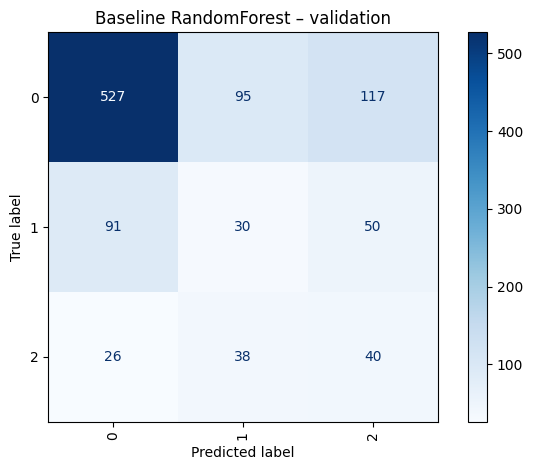

In [16]:
# baseline classifier
rf_clf = RandomForestClassifier(
    n_estimators=2,
    n_jobs=1,
    random_state=7,
    max_depth=8
)

# train
rf_clf.fit(X_train, y_train)

# predictions
y_train_pred = rf_clf.predict(X_train)
y_val_pred   = rf_clf.predict(X_val)

# accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy   = accuracy_score(y_val, y_val_pred)

print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")

# confusion matrix using validation set
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=90)
plt.title("Baseline RandomForest – validation")
plt.tight_layout()
plt.show()

### Make it better

In [97]:
pca = PCA(n_components=80, random_state=7)

pca.fit(X_train)

X_train_pca = pca.transform(X_train)
X_val_pca   = pca.transform(X_val)

In [144]:
# what if we try a regular random forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=800,         
    max_depth=None,               
    min_samples_leaf=6,       
    max_features="sqrt",       
    bootstrap=True,
    oob_score=True,           
    n_jobs=-1,                 
    random_state=7,
    verbose=1
)

rf.fit(X_train_pca, y_train)

# save model
joblib.dump(rf, "nhanes_rf_9.pkl")

# load model from file
gb2 = joblib.load("nhanes_rf_9.pkl")

# predictions
y_train_pred = gb2.predict(X_train_pca)
y_val_pred   = gb2.predict(X_val_pca)

# accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy   = accuracy_score(y_val, y_val_pred)

print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 800 out of 800 | elapsed:    1.9s finished


Train accuracy: 0.9996
Validation accuracy: 0.7387


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 800 out of 800 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 800 out of 800 | elapsed:    0.1s finished


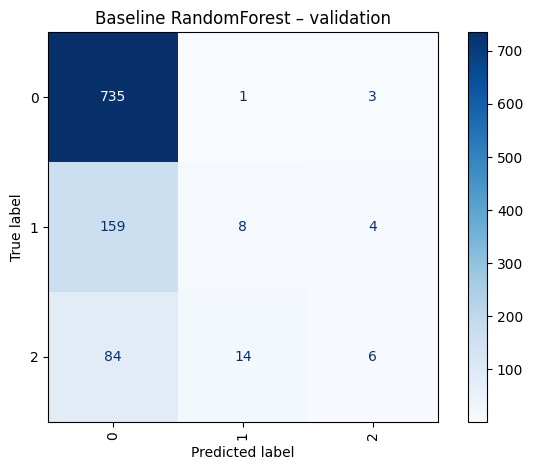

In [139]:
# confusion matrix using validation set
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=90)
plt.title("Baseline RandomForest – validation")
plt.tight_layout()
plt.show()

In [145]:
# test
X_test_pca = pca.transform(X_test)
y_test_pred = gb2.predict(X_test_pca)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test accuracy: {test_accuracy:.4f}")

Test accuracy: 0.7692


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:    0.2s
[Parallel(n_jobs=12)]: Done 800 out of 800 | elapsed:    0.2s finished


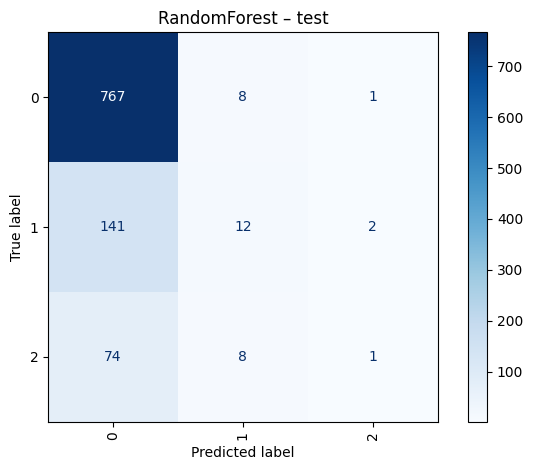

In [147]:
# confusion matrix using test set
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=90)
plt.title("RandomForest – test")
plt.tight_layout()
plt.show()

### what if we changed the task to binary?

In [152]:
y_train_bin = np.where(y_train > 0, 1, 0)
y_val_bin   = np.where(y_val > 0, 1, 0)
y_test_bin  = np.where(y_test > 0, 1, 0)

rf = RandomForestClassifier(
    n_estimators=800,         
    max_depth=None,               
    min_samples_leaf=6,       
    max_features="sqrt",       
    bootstrap=True,
    oob_score=True,           
    n_jobs=-1,                 
    random_state=7,
    verbose=1
)

rf.fit(X_train_pca, y_train_bin)

# save model
joblib.dump(rf, "nhanes_rf_9.pkl")

# load model from file
gb2 = joblib.load("nhanes_rf_9.pkl")

# predictions
y_train_pred = gb2.predict(X_train_pca)
y_val_pred   = gb2.predict(X_val_pca)

# accuracies
train_accuracy = accuracy_score(y_train_bin, y_train_pred)
val_accuracy   = accuracy_score(y_val_bin, y_val_pred)

print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 800 out of 800 | elapsed:    1.6s finished


Train accuracy: 0.9984
Validation accuracy: 0.7633


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 800 out of 800 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 800 out of 800 | elapsed:    0.1s finished


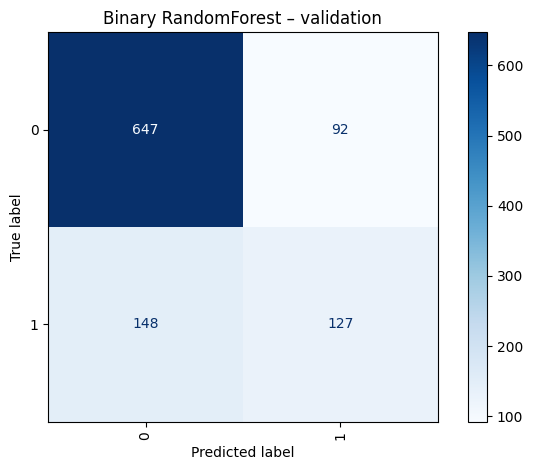

In [156]:
# confusion matrix using validation set
cm = confusion_matrix(y_val_bin, y_val_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=90)
plt.title("Binary RandomForest – validation")
plt.tight_layout()
plt.show()

In [154]:
# test
y_test_pred = gb2.predict(X_test_pca)
test_accuracy = accuracy_score(y_test_bin, y_test_pred)
print(f"Test accuracy: {test_accuracy:.4f}")

Test accuracy: 0.7673


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 800 out of 800 | elapsed:    0.1s finished


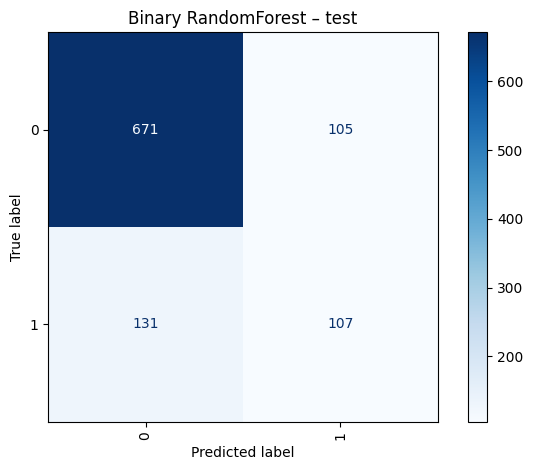

In [155]:
# confusion matrix using validation set
cm = confusion_matrix(y_test_bin, y_test_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=90)
plt.title("Binary RandomForest – test")
plt.tight_layout()
plt.show()

### XGBoost

In [171]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=20,     
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,           
    random_state=7,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

joblib.dump(xgb, "nhanes_xgb_1.pkl")

# predictions
y_train_pred = xgb.predict(X_train)
y_val_pred   = xgb.predict(X_val)

# accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy   = accuracy_score(y_val, y_val_pred)

print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")

Train accuracy: 0.9957
Validation accuracy: 0.7288


In [172]:
xgb = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=20,
    min_child_weight=5,     
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=5.0,  
    gamma=0.1,         
    random_state=7,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb.fit(X_train_pca, y_train)

joblib.dump(xgb, "nhanes_xgb_2.pkl")

# predictions
y_train_pred = xgb.predict(X_train_pca)
y_val_pred   = xgb.predict(X_val_pca)

# accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy   = accuracy_score(y_val, y_val_pred)

print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")

Train accuracy: 1.0000
Validation accuracy: 0.7357


In [173]:
xgb = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=10,
    min_child_weight=5,     
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,  
    gamma=0.1,         
    random_state=7,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

joblib.dump(xgb, "nhanes_xgb_2.pkl")

# predictions
y_train_pred = xgb.predict(X_train)
y_val_pred   = xgb.predict(X_val)

# accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy   = accuracy_score(y_val, y_val_pred)

print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")

Train accuracy: 1.0000
Validation accuracy: 0.7337


### XGBoost with undersampled data 

In [24]:
X_train_raw = pd.read_parquet("../data/model_raw/X_train.parquet")
y_train_raw = pd.read_parquet("../data/model_raw/Y_train.parquet")
y_train_raw = np.where(y_train_raw['depression_severity'] > 0, 1, 0)

under_sampler = RandomUnderSampler(random_state=0)
x_train_under_bin, y_train_under_bin = under_sampler.fit_resample(X_train_raw, y_train_raw)

X_val = pd.read_parquet("../data/model_raw/X_val.parquet")
y_val = pd.read_parquet("../data/model_raw/Y_val.parquet")
y_val = np.where(y_val['depression_severity'] > 0, 1, 0)


In [ ]:
x_train_under_bin.shape

In [ ]:
#Create XGBoost Model from x_train_under (underscaled) data for binary label
from xgboost import XGBClassifier


xgb_bin_under = XGBClassifier(
    objective='binary:logistic',
    num_boost_round=100,
    learning_rate=0.01,     
    max_depth=10,            
    n_estimators=1000,      
    subsample=0.8,          
    colsample_bytree=0.8,   
    reg_alpha=0.1,       
    reg_lambda=1,         
    gamma=0,       
    random_state=7,       
    booster='dart',    
    tree_method='auto',
    eval_metric = 'auc' 
)
xgb_bin_under.fit(x_train_under_bin, y_train_under_bin)
                               
# predictions
y_train_pred = xgb_bin_under.predict(x_train_under_bin)
y_val_pred   = xgb_bin_under.predict(X_val)

# accuracies
train_accuracy = accuracy_score(y_train_under_bin, y_train_pred)
val_accuracy   = accuracy_score(y_val, y_val_pred)

print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")

Train accuracy: 1.0000
Validation accuracy: 0.7012


In [42]:
print("class 1 recall: " + str(classification_report(y_val, y_val_pred, output_dict=True)["1"]['recall']))

class 1 recall: 0.5454545454545454


Train accuracy: 0.7835
Validation accuracy: 0.5966


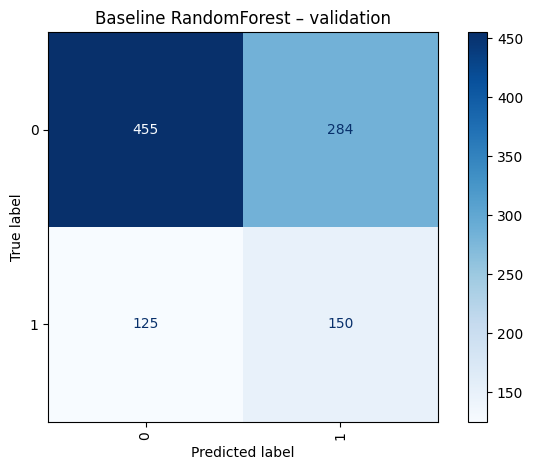

In [38]:
#### baseline model
base_rf_clf = RandomForestClassifier(
    n_estimators=2,
    n_jobs=1,
    random_state=7,
    max_depth=8
)

# train
base_rf_clf.fit(x_train_under_bin, y_train_under_bin)

# predictions
y_train_pred = base_rf_clf.predict(x_train_under_bin)
y_val_pred   = base_rf_clf.predict(X_val)

# accuracies
train_accuracy = accuracy_score(y_train_under_bin, y_train_pred)
val_accuracy   = accuracy_score(y_val, y_val_pred)

print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")

# confusion matrix using validation set
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=90)
plt.title("Baseline RandomForest – validation")
plt.tight_layout()
plt.show()

In [39]:
classification_report(y_val, y_val_pred, output_dict=True)

{'0': {'precision': 0.7844827586206896,
  'recall': 0.6156968876860622,
  'f1-score': 0.6899166034874905,
  'support': 739.0},
 '1': {'precision': 0.3456221198156682,
  'recall': 0.5454545454545454,
  'f1-score': 0.4231311706629055,
  'support': 275.0},
 'accuracy': 0.596646942800789,
 'macro avg': {'precision': 0.5650524392181789,
  'recall': 0.5805757165703038,
  'f1-score': 0.5565238870751981,
  'support': 1014.0},
 'weighted avg': {'precision': 0.6654623684122272,
  'recall': 0.596646942800789,
  'f1-score': 0.6175635521790478,
  'support': 1014.0}}

In [87]:
### baseline guessing based on the distribution of the raw training dataset
y_train_raw_a = pd.read_parquet("../data/model_raw/Y_train.parquet")
y_train_raw_a['dep_bin'] = np.where(y_train_raw_a['depression_severity'] > 0, 1, 0)
counts = pd.DataFrame(y_train_raw_a['dep_bin'].value_counts()).reset_index()


guess_0 = counts[counts['dep_bin'] == 0]['count']/counts['count'].sum()
guess_1 = counts[counts['dep_bin'] == 1]['count'] / counts['count'].sum()

In [91]:
ones = np.ones(round(len(y_train_raw_a) * guess_1).astype(int))
zeros = np.zeros(round(len(y_train_raw_a) * guess_0).astype(int))

out = np.concatenate((ones, zeros))
random_df = pd.DataFrame(out, columns=['pred'])

np.random.seed(12345)
indices = random_df.index.tolist()
shuffled_indices = np.random.permutation(indices)
random_df = random_df.reindex(shuffled_indices)

In [92]:
classification_report(np.array(y_train_raw_a['dep_bin']), np.array(random_df['pred']), output_dict=True)

{'0': {'precision': 0.7470093043863536,
  'recall': 0.7470093043863536,
  'f1-score': 0.7470093043863536,
  'support': 2257.0},
 '1': {'precision': 0.2707535121328225,
  'recall': 0.2707535121328225,
  'f1-score': 0.2707535121328225,
  'support': 783.0},
 'accuracy': 0.6243421052631579,
 'macro avg': {'precision': 0.508881408259588,
  'recall': 0.508881408259588,
  'f1-score': 0.508881408259588,
  'support': 3040.0},
 'weighted avg': {'precision': 0.6243421052631579,
  'recall': 0.6243421052631579,
  'f1-score': 0.6243421052631579,
  'support': 3040.0}}

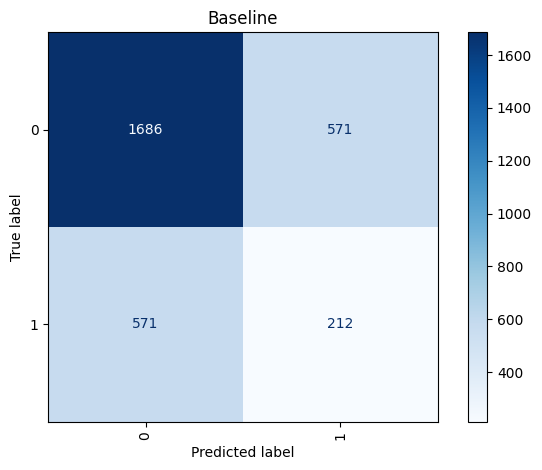

In [94]:
# confusion matrix using validation set
cm = confusion_matrix(np.array(y_train_raw_a['dep_bin']), np.array(random_df['pred']))
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=90)
plt.title("Baseline")
plt.tight_layout()
plt.show()

In [73]:
len(X_train_raw)

3040

In [61]:
len(y_train_raw_a) * guess_0

0    2257.0
Name: count, dtype: float64

In [67]:
round(len(y_train_raw_a) * guess_0).astype(int)

0    2257
Name: count, dtype: int64